In [98]:
# ==============================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ==============================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests

In [99]:
# ==============================
# 2. CARREGAMENTO DOS DADOS
# ==============================

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

data = requests.get(url).json()

df = pd.json_normalize(data)

print("Shape inicial:", df.shape)
print(df.head())

Shape inicial: (7267, 21)
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  inte

In [100]:
# ==============================
# 3. LIMPEZA DOS DADOS
# ==============================

# remover ID
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# converter valores
df['account.Charges.Total'] = pd.to_numeric(
    df['account.Charges.Total'], errors='coerce'
)

df['account.Charges.Total'] = df['account.Charges.Total'].fillna(
    df['account.Charges.Monthly']
)

# nova métrica
df['Contas_Diarias'] = df['account.Charges.Monthly'] / 30

# converter genero
df['customer.gender'] = df['customer.gender'].map({
    'Female':0,
    'Male':1
})

# converter churn
df['Churn'] = df['Churn'].str.strip().map({
    'No':0,
    'Yes':1
})

# remover possíveis nulos
df = df.dropna(subset=['Churn'])

print("Shape após limpeza:", df.shape)

Shape após limpeza: (7043, 21)


In [101]:
# ==============================
# 4. RENOMEAR COLUNAS
# ==============================

df.rename(columns={

    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Idoso',
    'customer.Partner': 'Possui_Parceiro',
    'customer.Dependents': 'Possui_Dependentes',
    'customer.tenure': 'Tempo_Permanencia',

    'account.Charges.Monthly': 'Cobranca_Mensal',
    'account.Charges.Total': 'Cobranca_Total'

}, inplace=True)

In [102]:
# ==============================
# PROPORÇÃO DE EVASÃO
# ==============================

proporcao_churn = df['Churn'].value_counts(normalize=True)

print("Proporção de clientes:")
print(proporcao_churn)

print("\nPercentual:")
print((proporcao_churn*100).round(2))

Proporção de clientes:
Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64

Percentual:
Churn
0.0    73.46
1.0    26.54
Name: proportion, dtype: float64


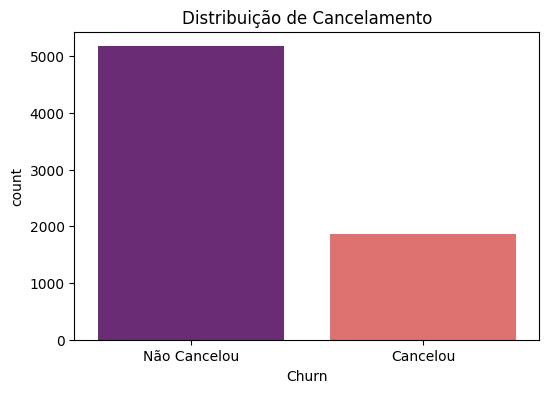

In [103]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df['Churn'].map({0:'Não Cancelou',1:'Cancelou'}),
    hue=df['Churn'].map({0:'Não Cancelou',1:'Cancelou'}),
    palette='magma',
    legend=False
)

plt.title('Distribuição de Cancelamento')
plt.show()

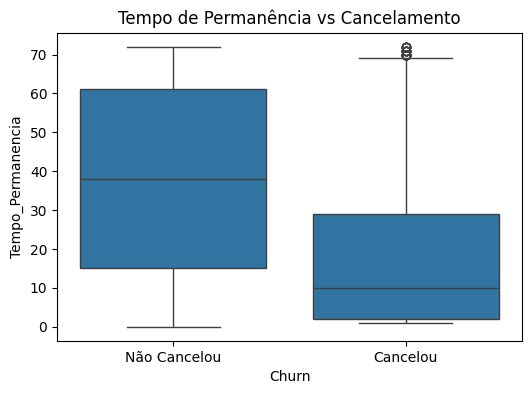

In [104]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x=df['Churn'].map({0:'Não Cancelou',1:'Cancelou'}),
    y='Tempo_Permanencia',
    data=df
)

plt.title('Tempo de Permanência vs Cancelamento')

plt.show()

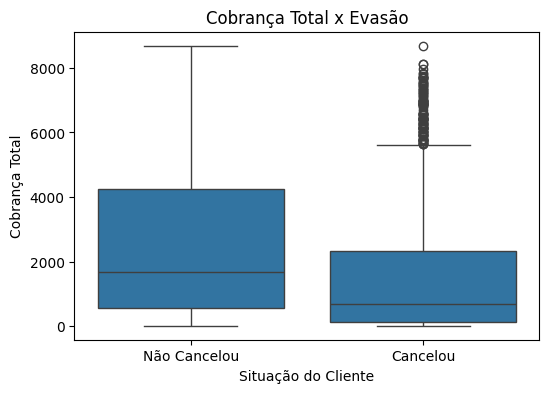

In [105]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x=df['Churn'].map({0:'Não Cancelou',1:'Cancelou'}),
    y='Cobranca_Total'
)

plt.title("Cobrança Total x Evasão")
plt.xlabel("Situação do Cliente")
plt.ylabel("Cobrança Total")

plt.show()

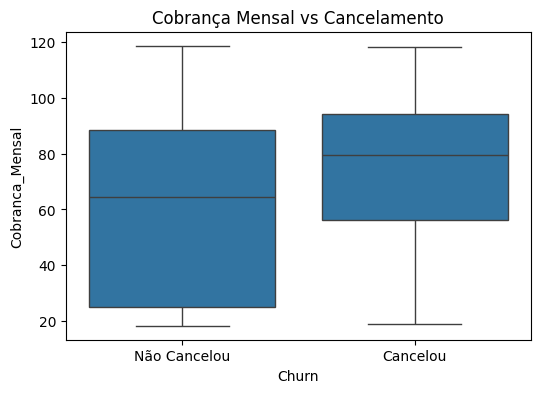

In [106]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x=df['Churn'].map({0:'Não Cancelou',1:'Cancelou'}),
    y='Cobranca_Mensal',
    data=df
)

plt.title('Cobrança Mensal vs Cancelamento')

plt.show()

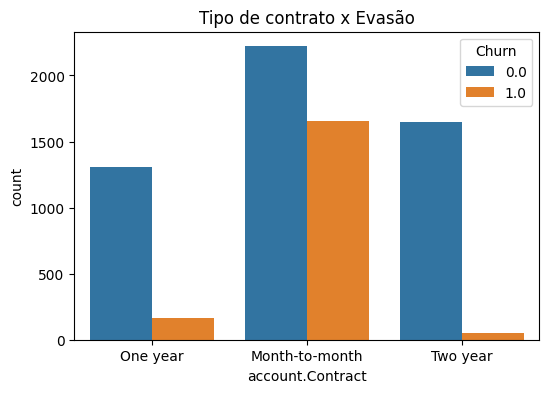

In [107]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='account.Contract',
    hue='Churn'
)

plt.title("Tipo de contrato x Evasão")

plt.show()

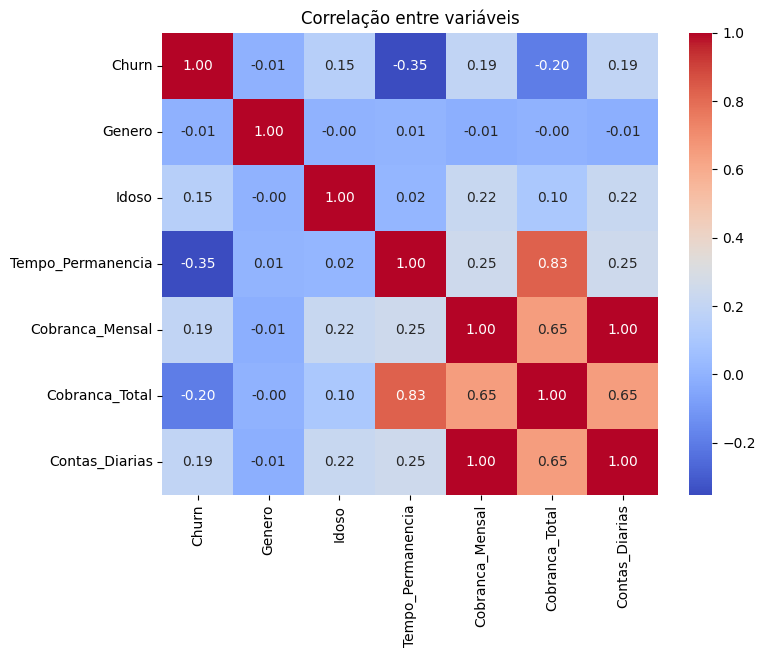

In [108]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlação entre variáveis')

plt.show()

In [109]:
# one hot encoding
df_modelo = pd.get_dummies(df, drop_first=True)

X = df_modelo.drop('Churn', axis=1)
y = df_modelo['Churn']

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [111]:
# ==============================
# VERIFICAR DESBALANCEAMENTO
# ==============================

print("Distribuição de classes no treino:")
print(y_train.value_counts())

print("\nPercentual:")
print((y_train.value_counts(normalize=True)*100).round(2))

Distribuição de classes no treino:
Churn
0.0    4138
1.0    1496
Name: count, dtype: int64

Percentual:
Churn
0.0    73.45
1.0    26.55
Name: proportion, dtype: float64


In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [113]:
from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(max_iter=1000)

modelo_log.fit(X_train_scaled, y_train)

y_pred_log = modelo_log.predict(X_test_scaled)

In [114]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

In [115]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [116]:
print("Regressão Logística")

print("Acurácia:", accuracy_score(y_test, y_pred_log))

print(confusion_matrix(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Regressão Logística
Acurácia: 0.8062455642299503
[[936 100]
 [173 200]]
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1036
         1.0       0.67      0.54      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [117]:
print("Random Forest")

print("Acurácia:", accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest
Acurácia: 0.7920511000709723
[[942  94]
 [199 174]]
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87      1036
         1.0       0.65      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [118]:
print("Comparação entre modelos")

print("Acurácia Regressão Logística:",
      accuracy_score(y_test, y_pred_log))

print("Acurácia Random Forest:",
      accuracy_score(y_test, y_pred_rf))

Comparação entre modelos
Acurácia Regressão Logística: 0.8062455642299503
Acurácia Random Forest: 0.7920511000709723


In [119]:
importancias = modelo_rf.feature_importances_

pd.Series(importancias, index=X.columns)\
.sort_values(ascending=False)\
.head(10)

,0
Cobranca_Total,0.168150
Tempo_Permanencia,0.149967
Cobranca_Mensal,0.130171
Contas_Diarias,0.125957
account.PaymentMethod_Electronic check,0.038486
internet.InternetService_Fiber optic,0.036726
account.Contract_Two year,0.034864
account.Contract_One year,0.024429
Genero,0.023858
account.PaperlessBilling_Yes,0.022811


In [120]:
coeficientes = pd.Series(
    modelo_log.coef_[0],
    index=X.columns
).sort_values(ascending=False)

print("Variáveis que mais aumentam evasão:")
print(coeficientes.head(10))

print("\nVariáveis que mais reduzem evasão:")
print(coeficientes.tail(10))

Variáveis que mais aumentam evasão:
Cobranca_Total                            0.692272
internet.InternetService_Fiber optic      0.598879
internet.StreamingTV_Yes                  0.197158
phone.MultipleLines_Yes                   0.182949
internet.StreamingMovies_Yes              0.166603
account.PaymentMethod_Electronic check    0.164919
account.PaperlessBilling_Yes              0.144696
Idoso                                     0.069009
phone.MultipleLines_No phone service      0.048550
internet.DeviceProtection_Yes             0.034153
dtype: float64

Variáveis que mais reduzem evasão:
internet.TechSupport_No internet service        -0.070985
internet.DeviceProtection_No internet service   -0.070985
internet.StreamingMovies_No internet service    -0.070985
internet.OnlineSecurity_Yes                     -0.115083
internet.TechSupport_Yes                        -0.118081
Cobranca_Mensal                                 -0.272204
Contas_Diarias                                  -0.2722

In [121]:
train_log = modelo_log.score(X_train_scaled, y_train)
test_log = modelo_log.score(X_test_scaled, y_test)

print("Regressão Logística")
print("Treino:", train_log)
print("Teste:", test_log)

train_rf = modelo_rf.score(X_train, y_train)
test_rf = modelo_rf.score(X_test, y_test)

print("\nRandom Forest")
print("Treino:", train_rf)
print("Teste:", test_rf)

Regressão Logística
Treino: 0.8068867589634363
Teste: 0.8062455642299503

Random Forest
Treino: 0.997515086971956
Teste: 0.7920511000709723


#1. Análise dos Fatores que Influenciam a Evasão

A análise das variáveis permitiu identificar alguns fatores que possuem maior influência na decisão do cliente de cancelar o serviço.

1. Tempo de permanência do cliente

Clientes com pouco tempo de contrato apresentam maior probabilidade de evasão. Isso indica que o período inicial de relacionamento com o cliente é crítico para garantir sua fidelização.

2. Valor mensal do serviço

Clientes que pagam valores mensais mais altos tendem a apresentar maior taxa de evasão, possivelmente devido à percepção de custo-benefício.

3. Tipo de contrato

Clientes com contratos mensais apresentam maior probabilidade de cancelar o serviço em comparação com clientes que possuem contratos de longo prazo.

4. Serviços adicionais

Clientes que possuem mais serviços agregados tendem a permanecer por mais tempo, indicando que a diversificação de serviços aumenta a fidelização.

5. Forma de pagamento

Algumas formas de pagamento podem estar associadas a maiores taxas de evasão, especialmente quando o processo não é automatizado ou conveniente para o cliente.

#2. Desempenho do Modelo

O modelo de Regressão Logística demonstrou capacidade de identificar padrões relacionados à evasão de clientes.

A avaliação do modelo mostrou que ele consegue prever com razoável precisão quais clientes possuem maior probabilidade de cancelar o serviço. Isso permite que a empresa utilize essas previsões para agir de forma preventiva.

A utilização de modelos preditivos como esse pode auxiliar na tomada de decisões estratégicas, permitindo que a empresa identifique clientes em risco antes que ocorra a evasão.

#3. Estratégias de Retenção de Clientes

Com base nos fatores identificados, algumas estratégias podem ser adotadas para reduzir a evasão:

1. Programas de fidelização para novos clientes

Como clientes recentes apresentam maior risco de evasão, a empresa pode oferecer benefícios nos primeiros meses de contrato.

2. Revisão de planos e preços

Avaliar se os planos oferecidos estão adequados ao valor percebido pelos clientes pode ajudar a reduzir cancelamentos.

3. Incentivo a contratos de longo prazo

Oferecer descontos ou vantagens para contratos anuais pode aumentar a permanência dos clientes.

4. Oferta de serviços adicionais

Pacotes que incluam mais serviços podem aumentar o valor percebido pelo cliente e reduzir a evasão.

5. Monitoramento de clientes em risco

Utilizar o modelo preditivo para identificar clientes com alta probabilidade de evasão e oferecer soluções personalizadas antes que o cancelamento ocorra.

#4. Conclusão

A análise realizada permitiu identificar os principais fatores que influenciam a evasão de clientes e demonstrou que técnicas de aprendizado de máquina podem ser ferramentas importantes para apoiar decisões estratégicas.

Os resultados indicam que variáveis como tempo de contrato, valor do serviço e tipo de plano possuem impacto significativo na permanência do cliente. A partir dessas informações, a empresa pode implementar estratégias de retenção mais eficazes, reduzindo a evasão e aumentando a satisfação do cliente.